## Codveda Level 2 — Task 1: Regression Analysis

### House Price Prediction Using Simple Linear Regression

In [2]:
#Importing libraries and load the dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#import Regression Model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [3]:
df= pd.read_csv("../data/4) house Prediction Data Set.csv",   sep=r"\s+",
    header=None)

In [4]:
#Inspecting and cleaning the dataset
df.shape

(506, 14)

In [5]:
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [5]:
#Assign column names
columns = [
    'CRIM',
    'ZN',
    'INDUS',
    'CHAS',
    'NOX',
    'RM',
    'AGE',
    'DIS',
    'RAD',
    'TAX',
    'PTRATIO',
    'B',
    'LSTAT',
    'MEDV'
]

df.columns = columns

In [7]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [8]:
df.shape

(506, 14)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [10]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [11]:
df.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
#Checking the correlation in the dataset
df.corr(numeric_only=True)["MEDV"].sort_values()

LSTAT     -0.737663
PTRATIO   -0.507787
INDUS     -0.483725
TAX       -0.468536
NOX       -0.427321
CRIM      -0.388305
RAD       -0.381626
AGE       -0.376955
CHAS       0.175260
DIS        0.249929
B          0.333461
ZN         0.360445
RM         0.695360
MEDV       1.000000
Name: MEDV, dtype: float64

In [14]:
#Examine the correlation between RM and MEDV
df[['RM', 'MEDV']].corr()

,RM,MEDV
RM,1.00000,0.69536
MEDV,0.69536,1.00000


The correlation analysis showed that LSTAT had the strongest negative
correlation with MEDV, while RM had the strongest positive correlation.

For this simple linear regression analysis, **RM (average number of rooms)**
was selected as the predictor because it has a relatively strong positive
relationship with MEDV and provides an intuitive relationship for
interpreting the regression model.

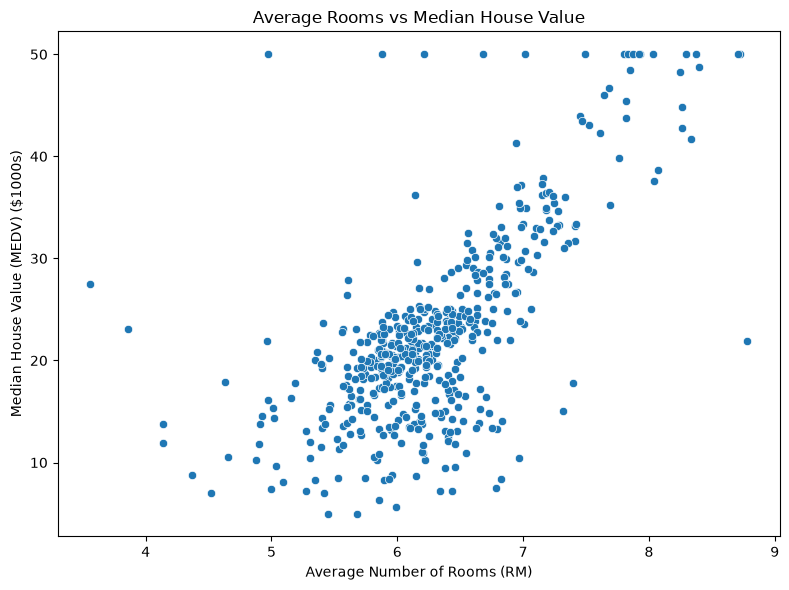

In [15]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='RM',
    y='MEDV'
)

plt.title('Average Rooms vs Median House Value')
plt.xlabel('Average Number of Rooms (RM)')
plt.ylabel('Median House Value (MEDV) ($1000s)')

plt.tight_layout()
plt.show()

Build the Linear Regression Model


In [16]:
#Define x and y variables
x= df[['RM']]
y= df['MEDV']

In [17]:
print(x.shape)
print(y.shape)

(506, 1)
(506,)


In [18]:
#Split the dataset into train and test
x_train, x_test, y_train, y_test = train_test_split (
    x,
    y,
    test_size=0.2,
    random_state=10
)

In [19]:
x_train.head()

,RM
50,5.963
367,3.863
34,6.096
78,6.232
172,5.572


In [20]:
x_test.head()

,RM
305,6.616
193,6.800
65,6.290
349,6.939
151,5.404


In [21]:
print("X_train:", x_train.shape)
print("X_test:", x_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (404, 1)
X_test: (102, 1)
y_train: (404,)
y_test: (102,)


In [22]:
#Create the linear regression model
model= LinearRegression()

In [23]:
#Train the model
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[8.64]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['RM']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-32.06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [24]:
model.coef_

array([8.63905126])

### Model Coefficient Interpretation

The regression coefficient for RM is approximately **8.64**.

According to the fitted model, an increase of one
average room is associated with an increase of approximately **8.64 units 
in MEDV**.

In [25]:
model.intercept_

np.float64(-32.058150019143866)

In [26]:
#Make predictions for the test data
y_pred = model.predict(x_test)

In [27]:
y_pred[:5]

array([25.09781312, 26.68739855, 22.28148241, 27.88822668, 14.62728299])

In [28]:
print("y_test shape:", y_test.shape)
print("y_pred shape:", y_pred.shape)

y_test shape: (102,)
y_pred shape: (102,)


In [29]:
#Compare predicted values with actual values:
results = pd.DataFrame({
    'Actual' : y_test,
    'Predicted' : y_pred
})

results.head(10)

,Actual,Predicted
305,28.4,25.097813
193,31.1,26.687399
65,23.5,22.281482
349,26.6,27.888227
151,19.6,14.627283
433,14.3,23.542784
161,50.0,32.639705
129,14.3,16.640182
269,20.7,19.085033
226,37.6,37.399822


In [30]:
#Evaluate the model
mse = mean_squared_error (y_test, y_pred)

print("Mean Squared Error :", mse)

Mean Squared Error : 45.60193447530386


In [31]:
rmse = np.sqrt(mse)

print ('Root Mean Squared Error :', rmse)

Root Mean Squared Error : 6.752920440468987


Since MEDV is expressed in thousands of dollars, the prediction error is around $6,750 in the target's original scale.

In [32]:
#Rsquare
r2 = r2_score (y_test, y_pred)

print("R-Squared :", r2)

R-Squared : 0.5639547666771445


### R-squared Interpretation

The model achieved an R² of approximately **0.564**.

This means that the average number of rooms (RM) explains approximately
**56.4% of the variation in median house value (MEDV) in the test data**.


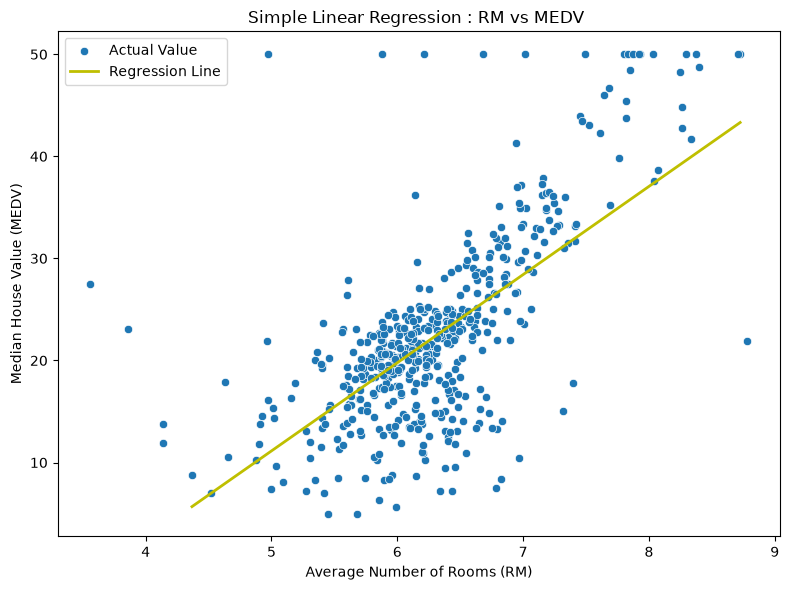

In [34]:
#Regression Model Visualization

plt.figure(figsize=(8,6))

sns.scatterplot(data= df, x='RM', y= 'MEDV', label="Actual Value")


plot_df = pd.DataFrame({'RM': x_test['RM'],'Predicted': y_pred}).sort_values('RM')

plt.plot( plot_df['RM'], plot_df['Predicted'],linewidth=2, color='y', label='Regression Line')

plt.title ("Simple Linear Regression : RM vs MEDV ")
plt.xlabel ("Average Number of Rooms (RM)")
plt.ylabel ("Median House Value (MEDV)")
plt.legend()

plt.tight_layout()
plt.show()

### Regression Equation

The fitted simple linear regression equation is:

**MEDV = -32.058 + 8.639 × RM**

where:

- **RM** = average number of rooms
- **MEDV** = predicted median house value in thousands of dollars

## Key Findings

1. RM and MEDV have a positive correlation of approximately **0.695**,
   indicating that properties with more rooms tend to have higher
   median values.

2. The fitted regression coefficient is approximately **8.64**, meaning
   that one additional average room is associated with an increase of
   approximately $8,640 in predicted median house value.

3. The model achieved an **R² of approximately 0.564**, indicating that
   RM alone explains about 56.4% of the variation in MEDV in the test data.

4. The model produced an **MSE of approximately 45.60** and an RMSE of
   approximately 6.75 in MEDV units.

5. Some actual and predicted values differ substantially, indicating that
   the number of rooms alone is not sufficient to explain all variation
   in house prices.

## Conclusion

A simple linear regression model was developed to predict median house
value (MEDV) using the average number of rooms (RM).

The analysis found a moderately strong positive relationship between RM
and MEDV. The model explained approximately 56.4% of the variation in
house values in the test data.

Although RM provides useful predictive information, the remaining
unexplained variation indicates that additional variables would be needed
to build a more accurate house-price prediction model.